# Skenario Prediktif Time Series: Pengaruh Konversi Tutupan Lahan dan Emisi Terhadap Anomali Suhu di Kawasan Asia Tenggara (ASEAN)

**Lembar Kerja Praktikum 10 - Eksplorasi Data**

---

## 1. Judul Projek

Model Prediksi Time Series: Pengaruh Konversi Tutupan Lahan dan Emisi Terhadap Anomali Suhu di Kawasan Asia Tenggara (ASEAN) Sebagai Early Warning System Berbasis Deep Learning.

## 2. Sumber Data

Data bersumber dari basis data resmi **Food and Agriculture Organization (FAO)** Perserikatan Bangsa-Bangsa:

| Domain | Link |
|--------|------|
| Data Suhu (GT) | https://www.fao.org/faostat/en/#data/GT |
| Data Emisi (ET) | https://www.fao.org/faostat/en/#data/ET |
| Data Tutupan Lahan (LC) | https://www.fao.org/faostat/en/#data/LC |

## 3. Penjelasan Data (Metadata & Deskripsi Atribut)

Dataset ini merupakan gabungan tiga domain utama:

**A. Data Iklim (Temperature Change / GT)**
- `Area`: Nama negara/wilayah
- `Year`: Tahun observasi (1992-2022)
- `Temperature_Change`: Anomali suhu permukaan (°C) relatif terhadap baseline 1951-1980

**B. Data Tutupan Lahan (Land Cover / LC)**
- `Artificial surfaces`: Luas permukaan buatan/urban (1000 ha)
- `Grassland`: Luas padang rumput
- `Herbaceous crops`: Luas tanaman herba
- `Tree-covered areas`: Luas area berhutan
- `Shrub-covered areas`: Luas area semak
- `Mangroves`: Luas hutan mangrove
- `Inland water bodies`: Luas perairan darat
- `Permanent snow and glaciers`: Luas salju/gletser permanen
- `Terrestrial barren land`: Luas lahan tandus
- `Woody crops`: Luas tanaman berkayu

**C. Data Emisi (Emissions / ET)**
- `AFOLU`: Agriculture, Forestry and Other Land Use emissions
- `Agrifood systems`: Total emisi sistem pangan
- `Energy`: Emisi dari sektor energi
- `LULUCF`: Land Use, Land-Use Change and Forestry
- `Enteric Fermentation`: Emisi dari fermentasi enterik
- `Forest fires`: Emisi dari kebakaran hutan
- `Net Forest conversion`: Emisi dari konversi hutan bersih
- Dan 30+ sub-kategori emisi lainnya

**Alur Logika:** Perubahan tutupan lahan → menghasilkan emisi → berakumulasi → memicu anomali suhu

## 4. Langkah-Langkah Pembacaan & Eksplorasi Data

### 4.1 Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:.2f}'.format)
print('Library berhasil diimport!')

Library berhasil diimport!


### 4.2 Membaca Dataset

In [2]:
df = pd.read_csv('Merged_Climate_LandCover_Data.csv')
print(f'Dataset berhasil dimuat!')
print(f'Jumlah baris: {df.shape[0]:,}')
print(f'Jumlah kolom: {df.shape[1]}')
print(f'Rentang tahun: {df["Year"].min()} - {df["Year"].max()}')
print(f'Jumlah Area unik: {df["Area"].nunique()}')
df.head()

Dataset berhasil dimuat!
Jumlah baris: 8,128
Jumlah kolom: 59
Rentang tahun: 1992 - 2022
Jumlah Area unik: 269


,Area,Year,Temperature_Change,Artificial surfaces (including urban and associated areas),Grassland,Herbaceous crops,Inland water bodies,Mangroves,Permanent snow and glaciers,Shrub-covered areas,...,Manure left on Pasture,Net Forest conversion,On-farm energy use,Other,Pesticides Manufacturing,Pre- and post-production,Rice Cultivation,Savanna fires,Synthetic Fertilizers,Waste
0,Afghanistan,1992,-0.32,25.26,24019.62,5759.76,268.55,0.00,322.06,3351.75,...,1653.49,0.00,2.98,16.25,NaN,467.47,686.00,8.76,214.65,466.34
1,Albania,1992,0.12,13.02,405.94,987.82,66.83,0.00,0.00,323.33,...,400.04,252.62,18.47,10.69,0.50,235.33,1.88,3.70,81.67,307.45
2,Algeria,1992,-0.34,80.64,825.84,8352.23,196.33,0.00,0.00,2064.52,...,2460.50,132.20,0.00,187.27,19.85,5643.00,4.47,31.93,257.69,4491.29
3,American Samoa,1992,0.47,0.03,1.60,2.77,5.59,0.16,0.00,1.14,...,NaN,8.83,15.65,NaN,NaN,42.82,NaN,0.00,NaN,NaN
4,Andorra,1992,0.36,0.19,10.93,0.31,0.01,0.00,0.00,0.78,...,NaN,12.77,NaN,2.23,0.07,17.38,NaN,0.00,NaN,16.31


### 4.3 Informasi Struktur Data

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 59 columns):
 #   Column                                                             Non-Null Count  Dtype  
---  ------                                                             --------------  -----  
 0   Area                                                               8128 non-null   object 
 1   Year                                                               8128 non-null   int64  
 2   Temperature_Change                                                 7810 non-null   float64
 3   Artificial surfaces (including urban and associated areas)         8128 non-null   float64
 4   Grassland                                                          8128 non-null   float64
 5   Herbaceous crops                                                   8128 non-null   float64
 6   Inland water bodies                                                8128 non-null   float64
 7   Mangroves               

### 4.4 Statistik Deskriptif

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Year,8128.00,2007.03,8.94,1992.00,1999.00,2007.00,2015.00,2022.00
Temperature_Change,7810.00,0.92,0.57,-1.86,0.55,0.88,1.24,3.70
Artificial surfaces (including urban and associated areas),8128.00,750.69,3422.84,0.00,3.78,32.20,193.33,64749.54
Grassland,8128.00,32865.95,133730.63,0.00,39.59,922.31,7618.13,1813817.46
Herbaceous crops,8128.00,34495.68,138813.76,0.00,31.35,1921.84,9424.20,1913692.10
Inland water bodies,8128.00,6910.20,33181.29,0.00,29.83,195.35,1312.42,436125.67
Mangroves,8128.00,366.00,1577.27,0.00,0.00,0.20,47.27,20607.85
Permanent snow and glaciers,8128.00,7999.17,88916.62,0.00,0.00,0.00,0.00,1405285.91
Shrub-covered areas,8128.00,29307.74,121521.78,0.00,14.88,444.08,6908.18,1611913.29
"Shrubs and/or herbaceous vegetation, aquatic or regularly flooded",8128.00,3368.87,16062.71,0.00,0.27,18.72,320.63,204706.75


### 4.5 Analisis Missing Values

In [5]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Jumlah Missing': missing, 'Persentase (%)': missing_pct})
missing_df = missing_df[missing_df['Jumlah Missing'] > 0].sort_values('Persentase (%)', ascending=False)
print(f'Kolom dengan missing values: {len(missing_df)} dari {df.shape[1]} kolom')
missing_df

Kolom dengan missing values: 31 dari 59 kolom


,Jumlah Missing,Persentase (%)
International bunkers,8097,99.62
Fertilizers Manufacturing,4701,57.84
Food Processing,3789,46.62
Rice Cultivation,3404,41.88
Food Packaging,3117,38.35
On-farm energy use,1919,23.61
Burning - Crop residues,1365,16.79
Crop Residues,1309,16.10
Enteric Fermentation,943,11.60
Manure applied to Soils,922,11.34


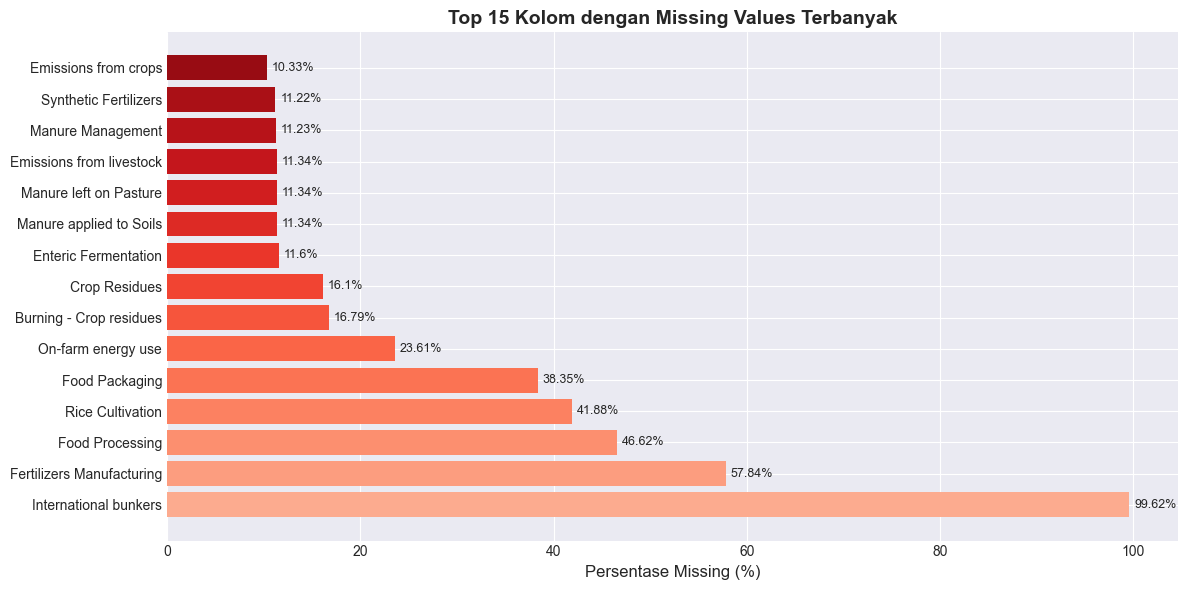

In [6]:
fig, ax = plt.subplots(figsize=(12, 6))
top_missing = missing_df.head(15)
colors = plt.cm.Reds(np.linspace(0.3, 0.9, len(top_missing)))
bars = ax.barh(top_missing.index, top_missing['Persentase (%)'], color=colors)
ax.set_xlabel('Persentase Missing (%)', fontsize=12)
ax.set_title('Top 15 Kolom dengan Missing Values Terbanyak', fontsize=14, fontweight='bold')
for bar, val in zip(bars, top_missing['Persentase (%)']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, f'{val}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()

**Interpretasi Missing Values:**
- `International bunkers` memiliki missing value tertinggi (~99.6%) karena tidak semua negara melaporkan emisi dari penerbangan/pelayaran internasional
- `Fertilizers Manufacturing`, `Food Processing`, `Food Packaging` juga tinggi karena data industri ini tidak tersedia untuk semua negara
- Kolom utama (`Temperature_Change`, `Area`, `Year`) memiliki missing value sangat rendah sehingga tetap layak dianalisis

## 5. Filtering Data Negara Asia Tenggara (ASEAN)

Kita memfilter dataset berdasarkan **10 negara anggota ASEAN** mengacu pada daftar resmi ASEAN Member States: Brunei Darussalam, Cambodia, Indonesia, Lao PDR, Malaysia, Myanmar, Philippines, Singapore, Thailand, dan Viet Nam.
Pendekatan ini memastikan analisis fokus pada negara-negara Asia Tenggara sesuai referensi resmi ASEAN.

Hasil filter akan disimpan ke `Merged_Climate_LandCover_Data_ASEAN.csv` agar bisa langsung dipakai pada run berikutnya.

In [7]:
# === Metode: Filter negara anggota ASEAN ===
# Daftar ASEAN Member States mengacu pada situs resmi ASEAN
import os

tropical_csv = 'Merged_Climate_LandCover_Data_ASEAN.csv'
asean_members = [
    'Brunei Darussalam',
    'Cambodia',
    'Indonesia',
    "Lao People's Democratic Republic",
    'Malaysia',
    'Myanmar',
    'Philippines',
    'Singapore',
    'Thailand',
    'Viet Nam'
]

if os.path.exists(tropical_csv):
    # Langsung gunakan file yang sudah difilter
    df_tropical = pd.read_csv(tropical_csv)
    print(f'Loaded pre-filtered ASEAN data: {tropical_csv}')
else:
    # Filter langsung dari data utama berdasarkan nama negara ASEAN di dataset FAOSTAT
    df_tropical = df[df['Area'].isin(asean_members)].copy()
    
    # Simpan hasil agar os.path.exists bekerja untuk run selanjutnya
    df_tropical.to_csv(tropical_csv, index=False)
    print(f'Filtered and saved ASEAN data to: {tropical_csv}')

print(f'Jumlah negara ASEAN: {df_tropical["Area"].nunique()}')
print(f'Total data points: {len(df_tropical):,}')
print(f'Rentang tahun: {df_tropical["Year"].min()} - {df_tropical["Year"].max()}')
print(f'\nDaftar negara ({df_tropical["Area"].nunique()}):')
for i, c in enumerate(sorted(df_tropical['Area'].unique()), 1):
    print(f'  {i:2d}. {c}')


Filtered and saved ASEAN data to: Merged_Climate_LandCover_Data_ASEAN.csv
Jumlah negara ASEAN: 10
Total data points: 310
Rentang tahun: 1992 - 2022

Daftar negara (10):
   1. Brunei Darussalam
   2. Cambodia
   3. Indonesia
   4. Lao People's Democratic Republic
   5. Malaysia
   6. Myanmar
   7. Philippines
   8. Singapore
   9. Thailand
  10. Viet Nam


## 6. Eksplorasi Data & Visualisasi

### 6.1 Tren Anomali Suhu di Negara ASEAN

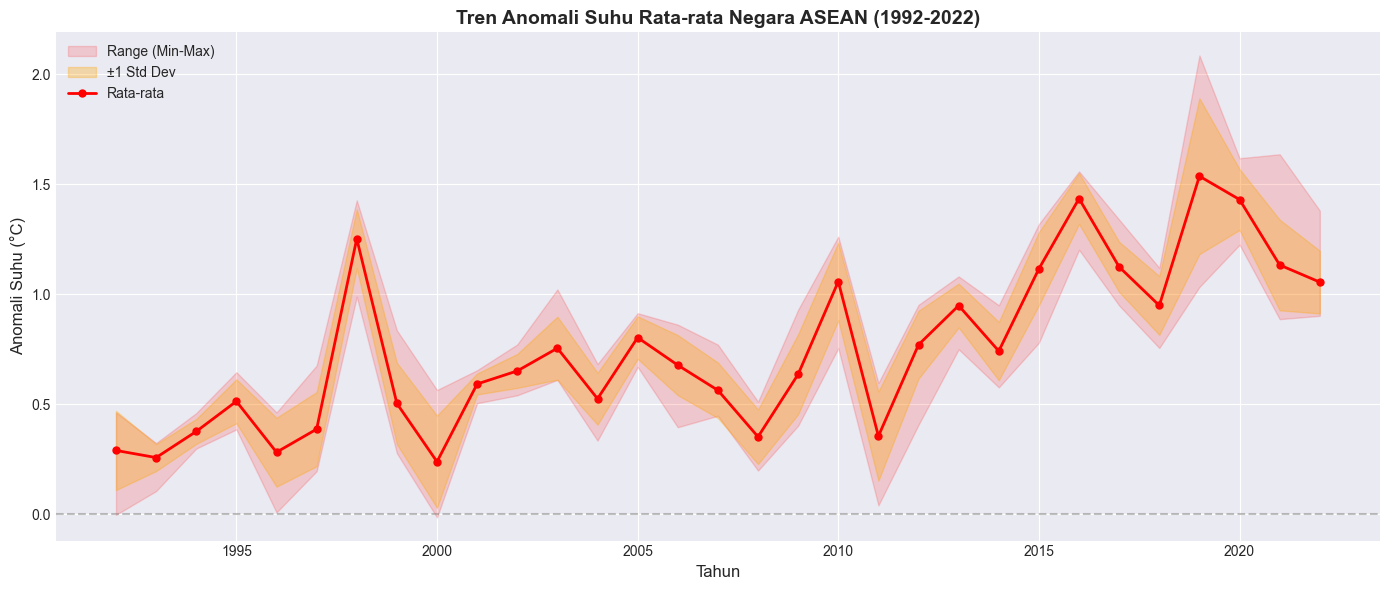

Anomali suhu rata-rata 1992: 0.291°C
Anomali suhu rata-rata 2022: 1.055°C
Peningkatan total: 0.765°C


In [8]:
# Rata-rata anomali suhu per tahun untuk seluruh negara ASEAN
temp_trend = df_tropical.groupby('Year')['Temperature_Change'].agg(['mean','std','min','max']).reset_index()

fig, ax = plt.subplots(figsize=(14, 6))
ax.fill_between(temp_trend['Year'], temp_trend['min'], temp_trend['max'], alpha=0.15, color='red', label='Range (Min-Max)')
ax.fill_between(temp_trend['Year'], temp_trend['mean']-temp_trend['std'], temp_trend['mean']+temp_trend['std'], alpha=0.3, color='orange', label='±1 Std Dev')
ax.plot(temp_trend['Year'], temp_trend['mean'], 'r-o', linewidth=2, markersize=5, label='Rata-rata')
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Tahun', fontsize=12)
ax.set_ylabel('Anomali Suhu (°C)', fontsize=12)
ax.set_title('Tren Anomali Suhu Rata-rata Negara ASEAN (1992-2022)', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()
print(f'Anomali suhu rata-rata 1992: {temp_trend["mean"].iloc[0]:.3f}°C')
print(f'Anomali suhu rata-rata 2022: {temp_trend["mean"].iloc[-1]:.3f}°C')
print(f'Peningkatan total: {temp_trend["mean"].iloc[-1] - temp_trend["mean"].iloc[0]:.3f}°C')

**Interpretasi:** Grafik menunjukkan tren kenaikan anomali suhu yang konsisten di kawasan Asia Tenggara dari 1992 hingga 2022. Peningkatan ini menunjukkan percepatan pemanasan global di negara-negara ASEAN.

### 6.2 Perbandingan Anomali Suhu antar Negara ASEAN

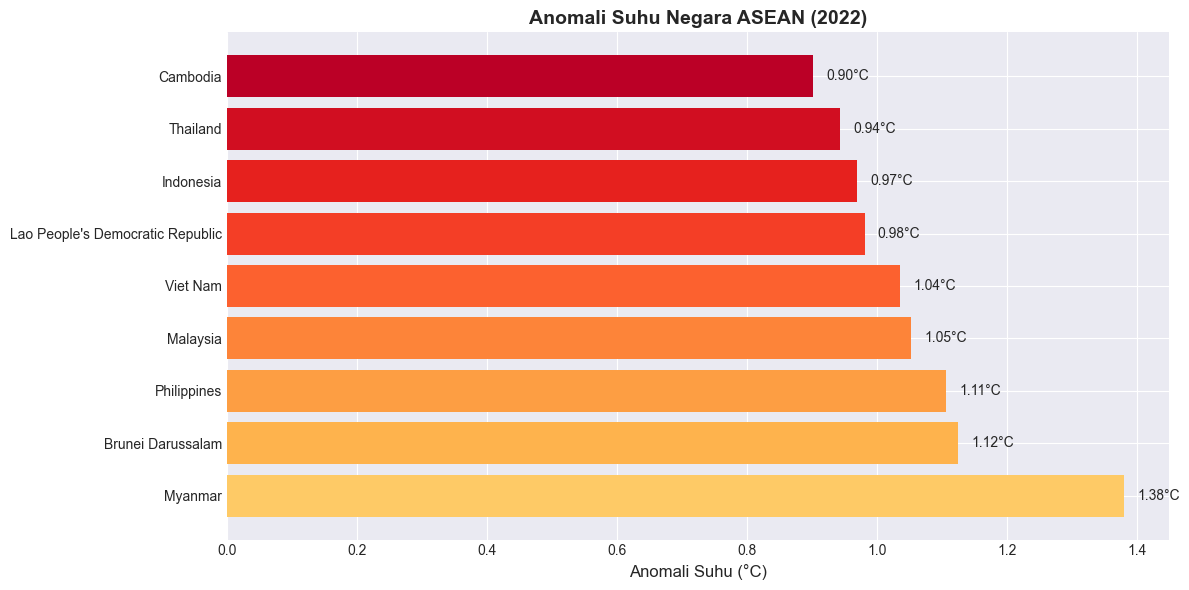

In [9]:
latest = df_tropical[df_tropical['Year'] == df_tropical['Year'].max()]
top10_hot = latest.nlargest(10, 'Temperature_Change')[['Area','Temperature_Change']]

fig, ax = plt.subplots(figsize=(12, 6))
colors = plt.cm.YlOrRd(np.linspace(0.3, 0.95, len(top10_hot)))
bars = ax.barh(top10_hot['Area'], top10_hot['Temperature_Change'], color=colors)
ax.set_xlabel('Anomali Suhu (°C)', fontsize=12)
ax.set_title(f'Anomali Suhu Negara ASEAN ({df_tropical["Year"].max()})', fontsize=14, fontweight='bold')
for bar, val in zip(bars, top10_hot['Temperature_Change']):
    ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2, f'{val:.2f}°C', va='center', fontsize=10)
plt.tight_layout()
plt.show()

### 6.3 Perubahan Tutupan Lahan di Negara ASEAN

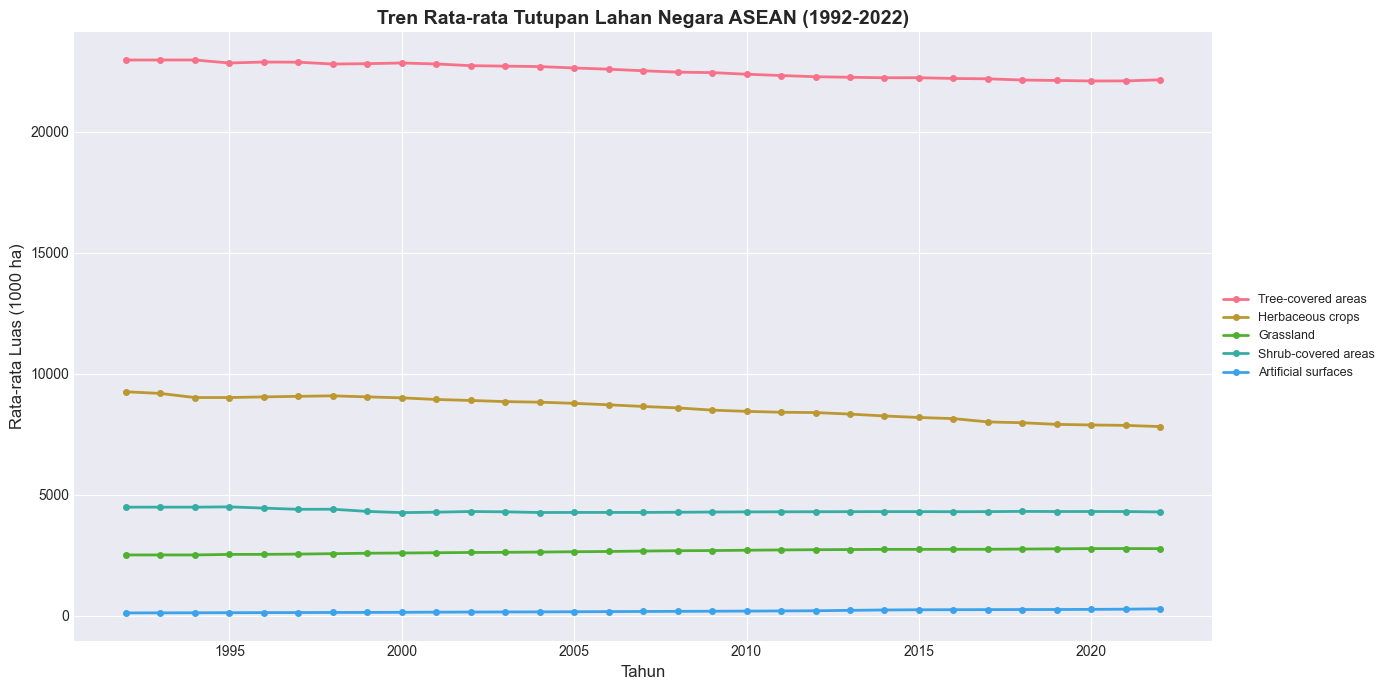

In [10]:
lc_cols = ['Tree-covered areas', 'Herbaceous crops', 'Grassland', 
           'Shrub-covered areas', 'Artificial surfaces (including urban and associated areas)']

lc_trend = df_tropical.groupby('Year')[lc_cols].mean().reset_index()

fig, ax = plt.subplots(figsize=(14, 7))
for col in lc_cols:
    short = col.replace(' (including urban and associated areas)', '')
    ax.plot(lc_trend['Year'], lc_trend[col], '-o', linewidth=2, markersize=4, label=short)
ax.set_xlabel('Tahun', fontsize=12)
ax.set_ylabel('Rata-rata Luas (1000 ha)', fontsize=12)
ax.set_title('Tren Rata-rata Tutupan Lahan Negara ASEAN (1992-2022)', fontsize=14, fontweight='bold')
ax.legend(fontsize=9, loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()

**Interpretasi:** Terlihat pola penurunan `Tree-covered areas` (deforestasi) dan peningkatan `Herbaceous crops` (ekspansi pertanian) serta `Artificial surfaces` (urbanisasi). Ini menunjukkan konversi lahan hutan menjadi lahan pertanian dan perkotaan di negara-negara ASEAN.

### 6.4 Tren Emisi Utama

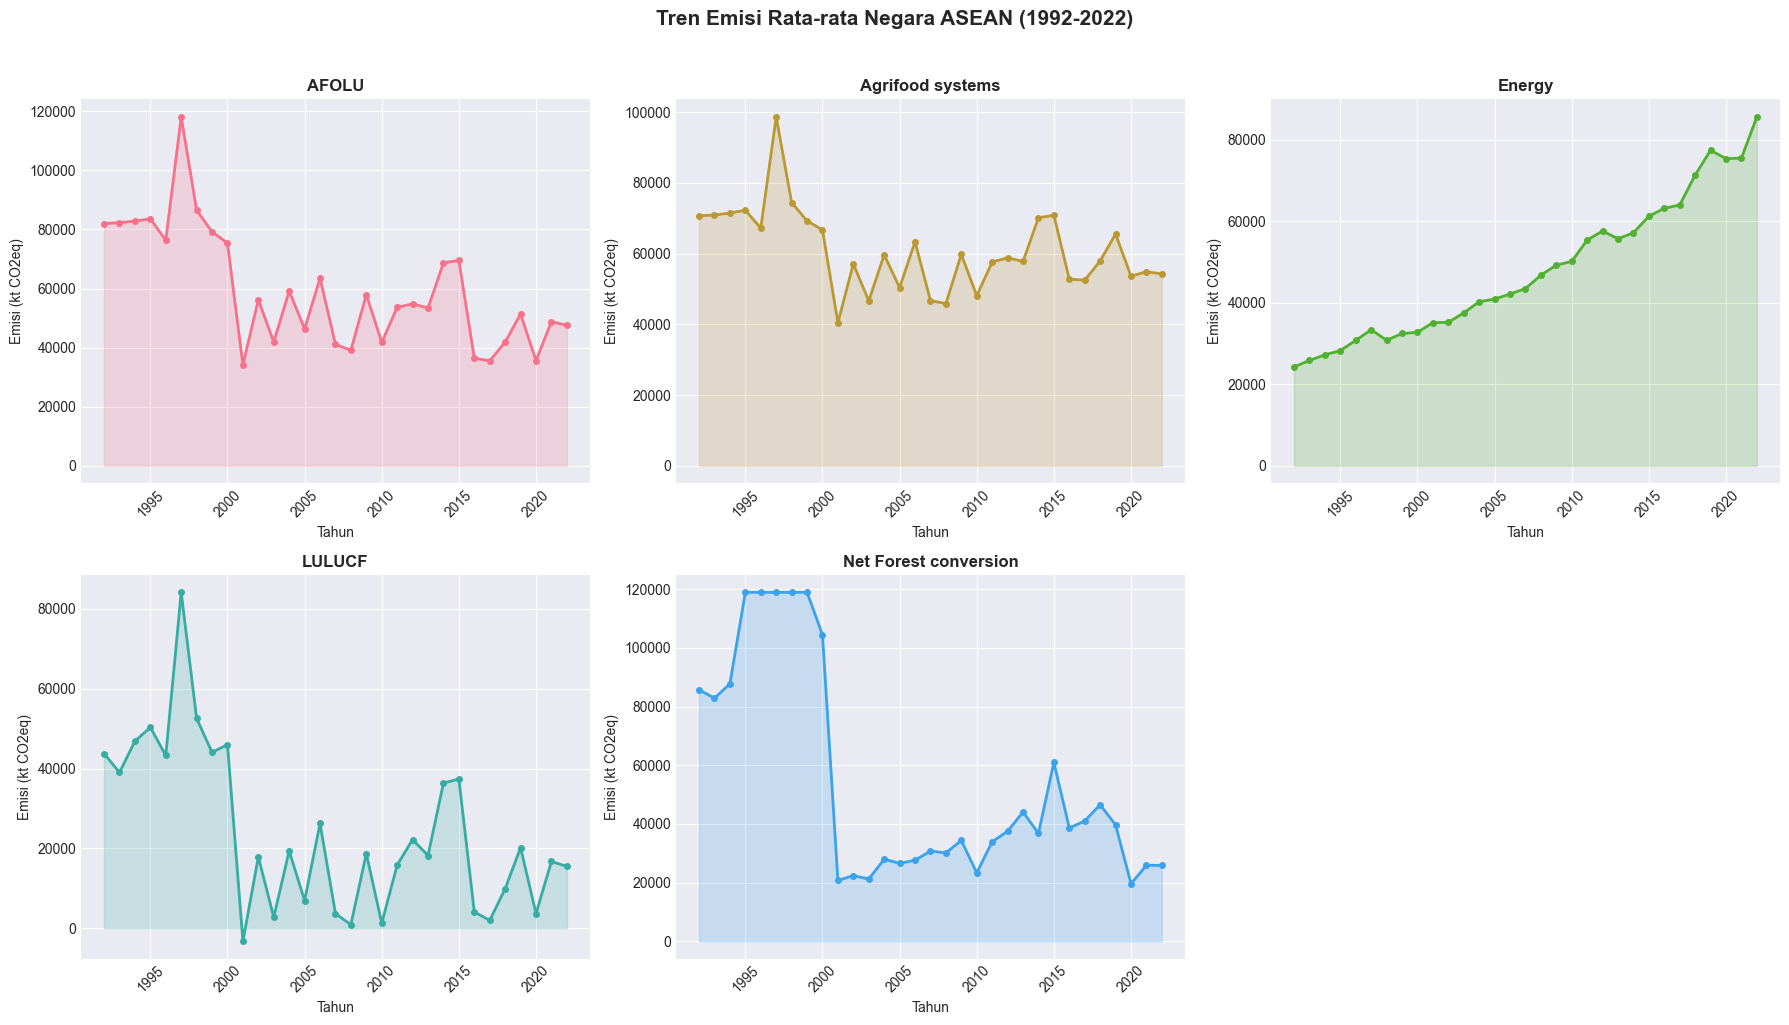

In [11]:
emission_cols = ['AFOLU', 'Agrifood systems', 'Energy', 'LULUCF', 'Net Forest conversion']
avail = [c for c in emission_cols if c in df_tropical.columns]

em_trend = df_tropical.groupby('Year')[avail].mean().reset_index()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for i, col in enumerate(avail):
    ax = axes[i]
    ax.plot(em_trend['Year'], em_trend[col], '-o', linewidth=2, markersize=4, color=f'C{i}')
    ax.fill_between(em_trend['Year'], 0, em_trend[col], alpha=0.2, color=f'C{i}')
    ax.set_title(col, fontsize=12, fontweight='bold')
    ax.set_xlabel('Tahun')
    ax.set_ylabel('Emisi (kt CO2eq)')
    ax.tick_params(axis='x', rotation=45)
for j in range(len(avail), len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Tren Emisi Rata-rata Negara ASEAN (1992-2022)', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 6.5 Heatmap Korelasi: Suhu vs Tutupan Lahan vs Emisi

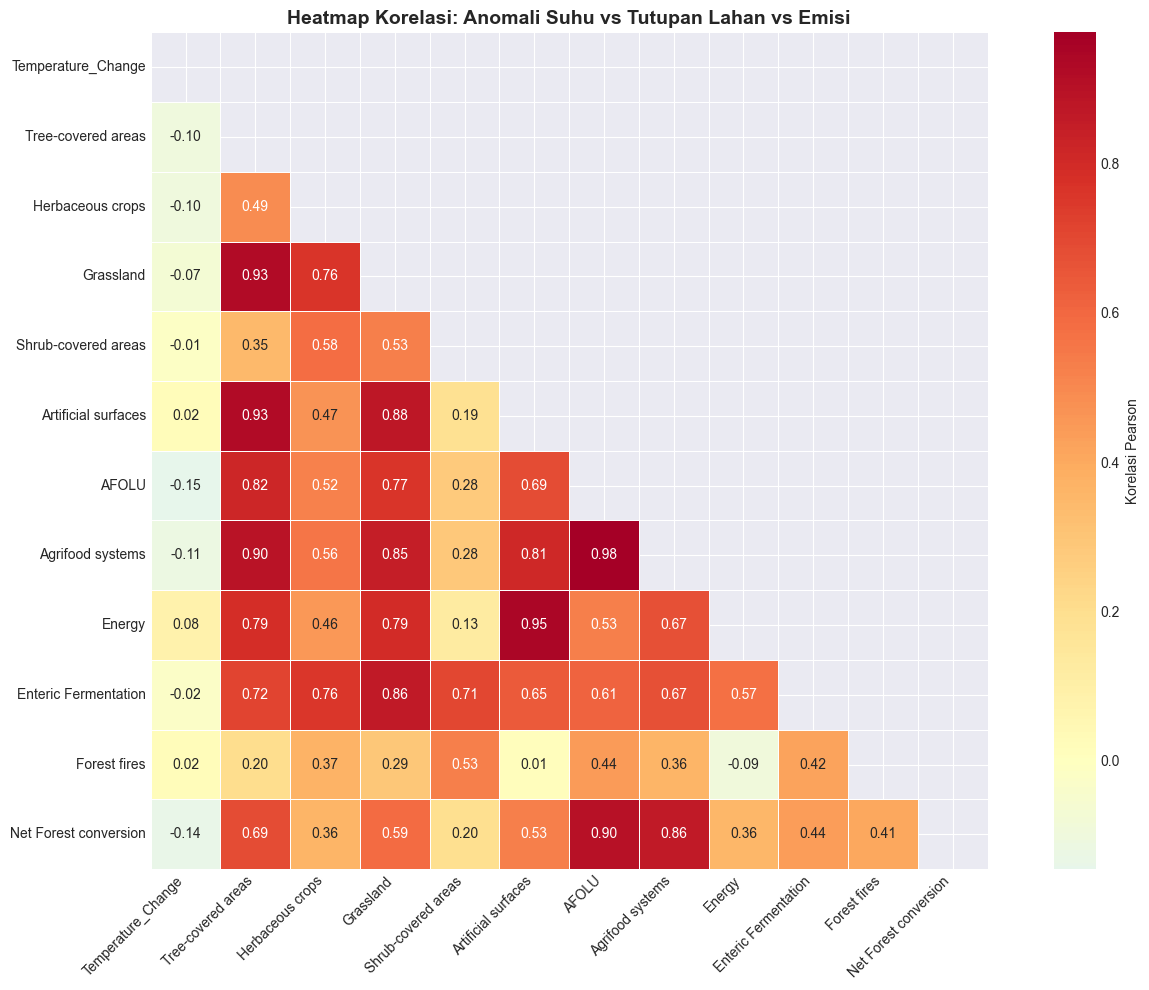

In [12]:
corr_cols = ['Temperature_Change'] + lc_cols + ['AFOLU', 'Agrifood systems', 'Energy', 'Enteric Fermentation', 'Forest fires', 'Net Forest conversion']
avail_corr = [c for c in corr_cols if c in df_tropical.columns]
corr_data = df_tropical[avail_corr].dropna()
corr_matrix = corr_data.corr()

fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
short_labels = [c.replace(' (including urban and associated areas)', '').replace('Shrubs and/or herbaceous vegetation, aquatic or regularly flooded', 'Aquatic Veg') for c in corr_matrix.columns]
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlBu_r',
            center=0, square=True, linewidths=0.5, ax=ax,
            xticklabels=short_labels, yticklabels=short_labels,
            cbar_kws={'label': 'Korelasi Pearson'})
ax.set_title('Heatmap Korelasi: Anomali Suhu vs Tutupan Lahan vs Emisi', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Interpretasi Korelasi:**
- Korelasi positif antara `Temperature_Change` dan `Artificial surfaces` menunjukkan urbanisasi berkontribusi pada pemanasan
- Korelasi negatif antara `Temperature_Change` dan `Tree-covered areas` mengkonfirmasi deforestasi meningkatkan anomali suhu
- `AFOLU` dan `Agrifood systems` menunjukkan korelasi kuat dengan emisi sub-sektor, validating integrasi data

### 6.6 Analisis Time Series: Studi Kasus Indonesia

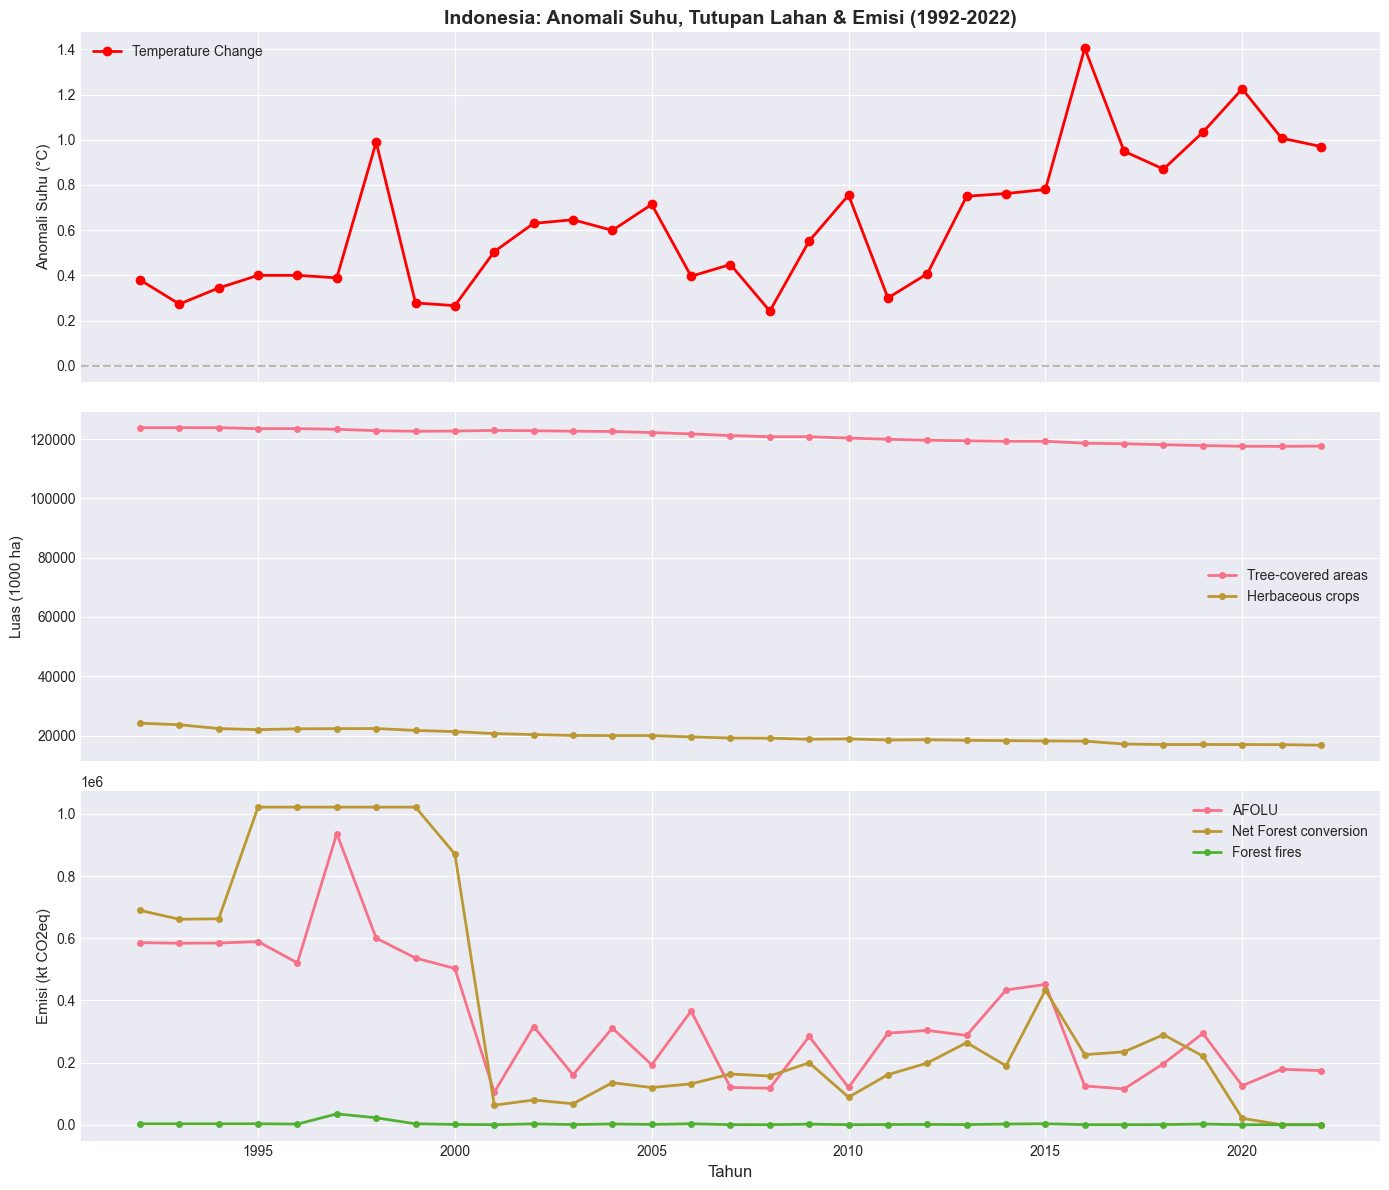

In [13]:
df_idn = df_tropical[df_tropical['Area'] == 'Indonesia'].sort_values('Year')

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# Panel 1: Temperature
axes[0].plot(df_idn['Year'], df_idn['Temperature_Change'], 'r-o', linewidth=2)
axes[0].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
axes[0].set_ylabel('Anomali Suhu (°C)', fontsize=11)
axes[0].set_title('Indonesia: Anomali Suhu, Tutupan Lahan & Emisi (1992-2022)', fontsize=14, fontweight='bold')
axes[0].legend(['Temperature Change'], loc='upper left')

# Panel 2: Land Cover
for col in ['Tree-covered areas', 'Herbaceous crops']:
    if col in df_idn.columns:
        axes[1].plot(df_idn['Year'], df_idn[col], '-o', linewidth=2, markersize=4, label=col)
axes[1].set_ylabel('Luas (1000 ha)', fontsize=11)
axes[1].legend(loc='center right')

# Panel 3: Emissions
for col in ['AFOLU', 'Net Forest conversion', 'Forest fires']:
    if col in df_idn.columns:
        axes[2].plot(df_idn['Year'], df_idn[col], '-o', linewidth=2, markersize=4, label=col)
axes[2].set_xlabel('Tahun', fontsize=12)
axes[2].set_ylabel('Emisi (kt CO2eq)', fontsize=11)
axes[2].legend(loc='upper right')

plt.tight_layout()
plt.show()

**Interpretasi Indonesia:**
- Anomali suhu menunjukkan tren naik yang konsisten
- Penurunan `Tree-covered areas` (deforestasi) terlihat jelas
- Spike emisi dari `Forest fires` dan `Net Forest conversion` berkorelasi dengan tahun-tahun kenaikan suhu ekstrem (1997-1998 El Niño, 2015-2016)

### 6.7 Scatter Plot: Deforestasi vs Anomali Suhu

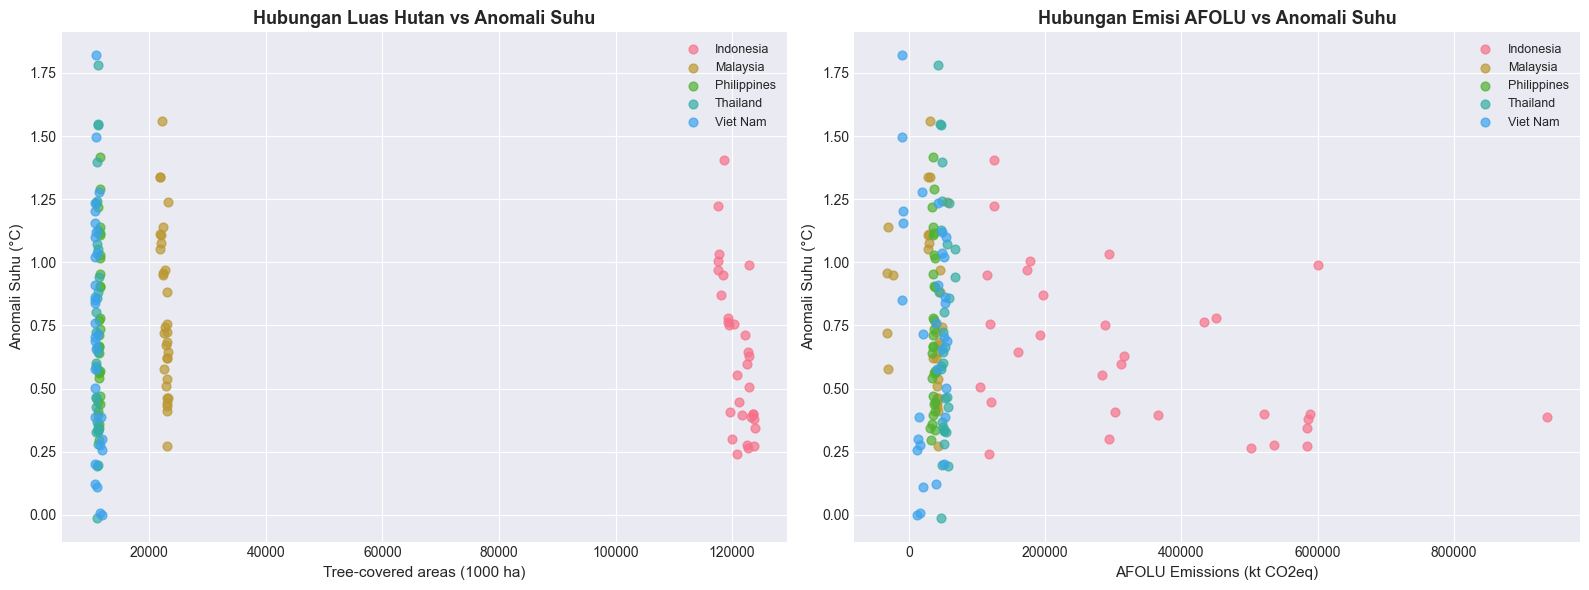

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter 1: Tree cover vs Temp
ax1 = axes[0]
for country in ['Indonesia', 'Malaysia', 'Philippines', 'Thailand', 'Viet Nam']:
    cdata = df_tropical[df_tropical['Area'] == country]
    ax1.scatter(cdata['Tree-covered areas'], cdata['Temperature_Change'], label=country, alpha=0.7, s=40)
ax1.set_xlabel('Tree-covered areas (1000 ha)', fontsize=11)
ax1.set_ylabel('Anomali Suhu (°C)', fontsize=11)
ax1.set_title('Hubungan Luas Hutan vs Anomali Suhu', fontsize=13, fontweight='bold')
ax1.legend(fontsize=9)

# Scatter 2: AFOLU vs Temp
ax2 = axes[1]
for country in ['Indonesia', 'Malaysia', 'Philippines', 'Thailand', 'Viet Nam']:
    cdata = df_tropical[df_tropical['Area'] == country]
    ax2.scatter(cdata['AFOLU'], cdata['Temperature_Change'], label=country, alpha=0.7, s=40)
ax2.set_xlabel('AFOLU Emissions (kt CO2eq)', fontsize=11)
ax2.set_ylabel('Anomali Suhu (°C)', fontsize=11)
ax2.set_title('Hubungan Emisi AFOLU vs Anomali Suhu', fontsize=13, fontweight='bold')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()

### 6.8 Distribusi Anomali Suhu per Dekade

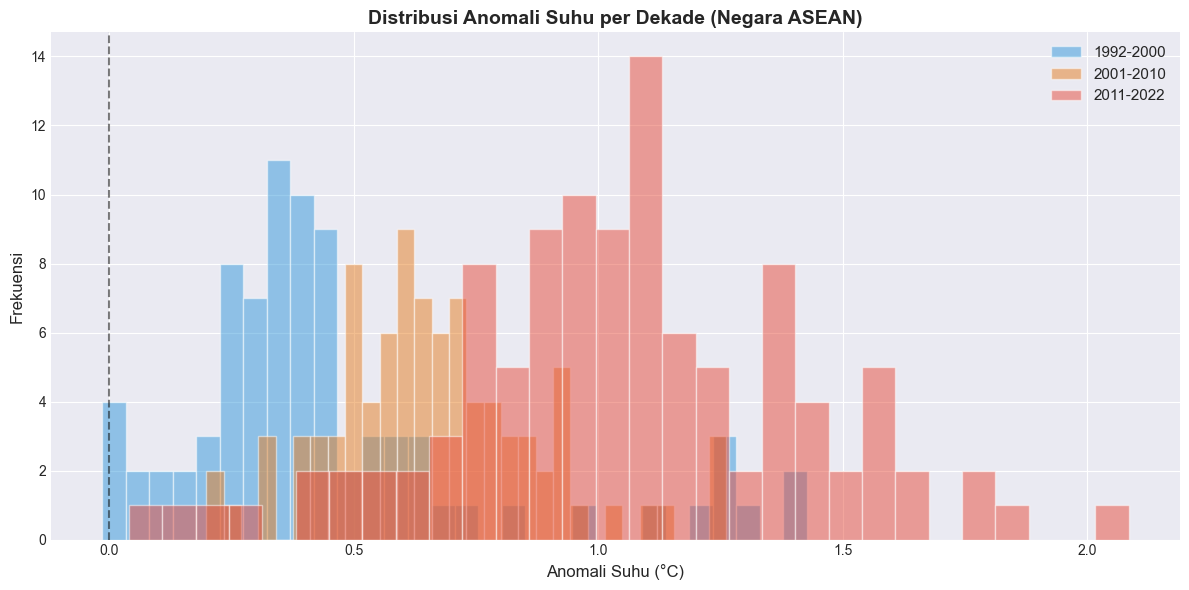

Statistik per Dekade:
           count  mean  std   min  25%  50%  75%  max
Dekade                                               
1992-2000  81.00  0.46 0.33 -0.01 0.27 0.39 0.54 1.43
2001-2010  90.00  0.66 0.22  0.20 0.52 0.64 0.77 1.26
2011-2022 108.00  1.05 0.36  0.04 0.86 1.06 1.25 2.08


In [15]:
df_tropical['Dekade'] = pd.cut(df_tropical['Year'], bins=[1991,2000,2010,2022], labels=['1992-2000','2001-2010','2011-2022'])

fig, ax = plt.subplots(figsize=(12, 6))
colors_d = ['#3498db', '#e67e22', '#e74c3c']
for i, dekade in enumerate(['1992-2000','2001-2010','2011-2022']):
    data = df_tropical[df_tropical['Dekade'] == dekade]['Temperature_Change'].dropna()
    ax.hist(data, bins=30, alpha=0.5, label=dekade, color=colors_d[i], edgecolor='white')
ax.axvline(x=0, color='black', linestyle='--', alpha=0.5)
ax.set_xlabel('Anomali Suhu (°C)', fontsize=12)
ax.set_ylabel('Frekuensi', fontsize=12)
ax.set_title('Distribusi Anomali Suhu per Dekade (Negara ASEAN)', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

print('Statistik per Dekade:')
print(df_tropical.groupby('Dekade')['Temperature_Change'].describe().round(3))

**Interpretasi Distribusi:**
- Distribusi anomali suhu bergeser ke kanan (lebih panas) dari dekade ke dekade
- Dekade 2011-2022 menunjukkan distribusi yang lebih condong ke anomali positif
- Ini mengkonfirmasi akselerasi pemanasan global di kawasan Asia Tenggara

### 6.9 Box Plot Anomali Suhu per Negara (Top 15)

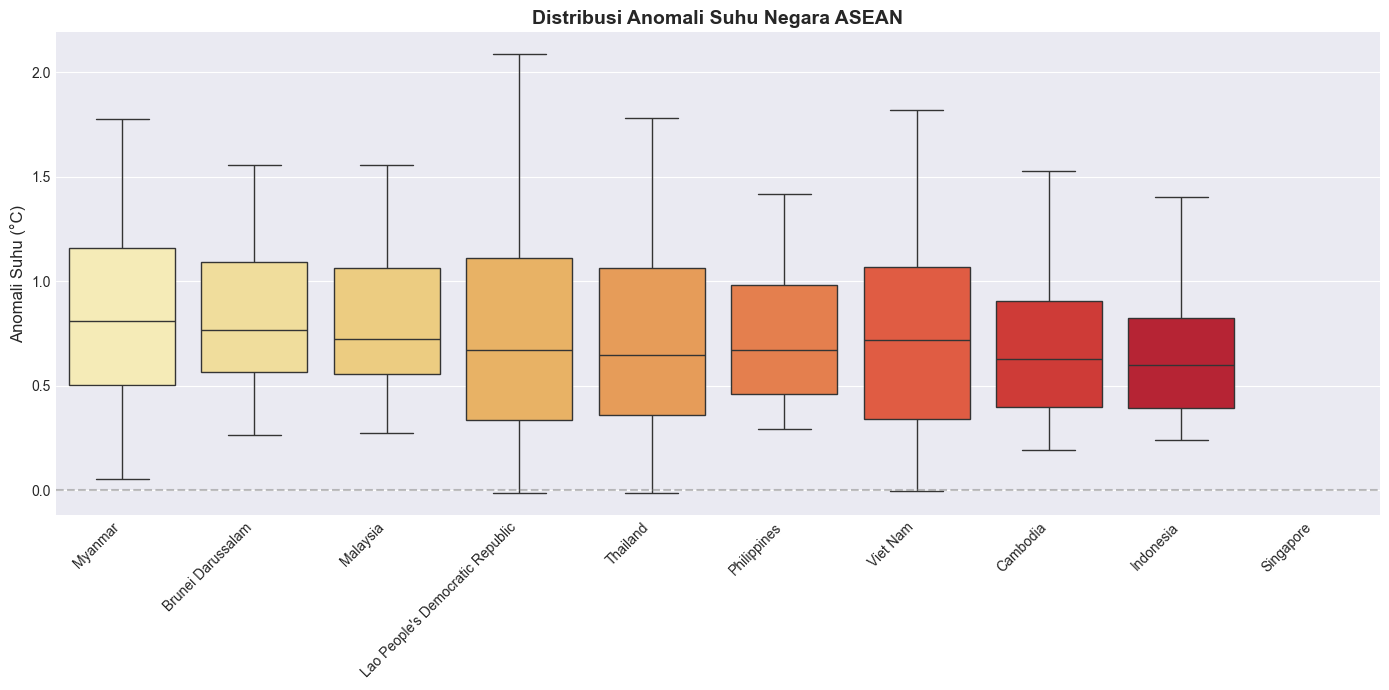

In [16]:
top15 = df_tropical.groupby('Area')['Temperature_Change'].mean().nlargest(15).index
df_top15 = df_tropical[df_tropical['Area'].isin(top15)]

fig, ax = plt.subplots(figsize=(14, 7))
order = df_top15.groupby('Area')['Temperature_Change'].mean().sort_values(ascending=False).index
sns.boxplot(data=df_top15, x='Area', y='Temperature_Change', order=order, palette='YlOrRd', ax=ax)
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('')
ax.set_ylabel('Anomali Suhu (°C)', fontsize=12)
ax.set_title('Distribusi Anomali Suhu Negara ASEAN', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 6.10 Pairplot: Variabel Kunci

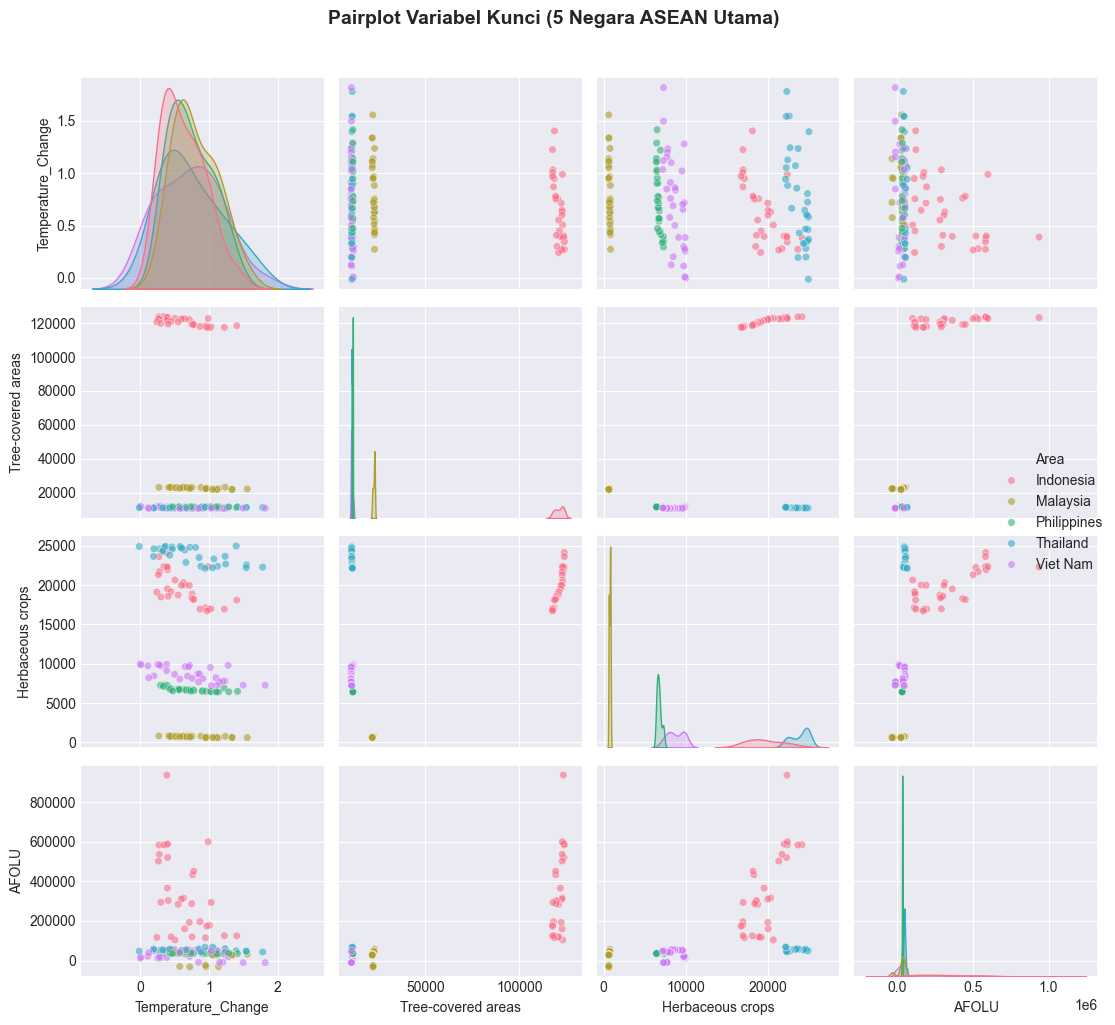

In [17]:
key_vars = ['Temperature_Change', 'Tree-covered areas', 'Herbaceous crops', 'AFOLU']
avail_kv = [c for c in key_vars if c in df_tropical.columns]
sample = df_tropical[avail_kv + ['Area']].dropna()
# Sample 5 negara ASEAN utama untuk clarity
five = ['Indonesia', 'Malaysia', 'Philippines', 'Thailand', 'Viet Nam']
sample5 = sample[sample['Area'].isin(five)]

g = sns.pairplot(sample5, hue='Area', vars=avail_kv, palette='husl', 
                 plot_kws={'alpha': 0.6, 's': 30}, diag_kind='kde', height=2.5)
g.figure.suptitle('Pairplot Variabel Kunci (5 Negara ASEAN Utama)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 7. Interpretasi Data & Kesimpulan

### 7.1 Temuan Utama

1. **Tren Pemanasan Konsisten**: Anomali suhu di kawasan Asia Tenggara meningkat secara konsisten dari 1992 hingga 2022, dengan percepatan yang lebih terasa setelah tahun 2010.

2. **Deforestasi Masif**: Terjadi penurunan signifikan pada `Tree-covered areas` yang diimbangi peningkatan `Herbaceous crops` dan `Artificial surfaces`, menunjukkan konversi lahan hutan untuk pertanian dan urbanisasi.

3. **Korelasi Emisi-Suhu**: Emisi dari sektor AFOLU (Agriculture, Forestry and Other Land Use) menunjukkan korelasi positif dengan anomali suhu, mengkonfirmasi bahwa perubahan penggunaan lahan berkontribusi pada pemanasan.

4. **Hotspot Indonesia**: Indonesia menunjukkan pola yang khas dengan spike emisi dari kebakaran hutan (terutama 1997-1998, 2015) yang berkorelasi dengan anomali suhu ekstrem.

5. **Distribusi Bergeser**: Distribusi anomali suhu bergeser ke arah positif dari dekade ke dekade, menunjukkan pemanasan sistematis.

### 7.2 Implikasi untuk Pemodelan LSTM

- Data time series yang konsisten (31 tahun) cocok untuk arsitektur LSTM/GRU
- Efek lagged antara deforestasi dan kenaikan suhu (2-5 tahun) dapat ditangkap oleh memori LSTM
- Missing values perlu ditangani dengan interpolasi sebelum pemodelan
- Feature selection berdasarkan korelasi dapat meningkatkan performa model

### 7.3 Potensi Early Warning System

Dengan tren yang teridentifikasi, model prediktif dapat:
- Memprediksi anomali suhu 5 tahun ke depan berdasarkan tren konversi lahan
- Memberikan peringatan dini jika suatu negara melampaui threshold deforestasi tertentu
- Membantu pengambil kebijakan dalam perencanaan mitigasi perubahan iklim

---

**Dibuat untuk Lembar Kerja Praktikum 10 - Data Mining**

Dataset: Merged_Climate_LandCover_Data.csv (FAO)